# RépétIA — Banc d'évaluation des modèles, avant tout entraînement

**Phase 1 du plan d'entraînement** (`recherche/PLAN_ENTRAINEMENT.md`)

---

## Pourquoi ce notebook existe

RépétIA veut son propre modèle de langue. Une première tentative, en
septembre, a annoncé un modèle entraîné et un score de 96,5/100 : aucun
entraînement n'avait eu lieu et les métriques étaient codées en dur (voir
`evolu.md`, entrée du 2026-09-03).

Ce notebook pose donc la règle avant le premier entraînement : **on mesure
d'abord, sur un jeu de test figé, ce que valent les modèles candidats tels
quels**, ainsi que la référence (Gemini) et le plancher (l'application sans
LLM). L'entraînement de la phase 3 ne sera jugé qu'à l'aune de ces chiffres.

## Protocole

**Jeu de test v1** — `recherche/donnees/banc/jeu_de_test.jsonl`, construit par
`recherche/src/exporter_banc.js` à graine fixe (reproductible octet pour
octet), avec les prompts **exacts** de production exportés de
`backend/src/services/llm.service.ts`. Il couvre le catalogue actuel
(6ème → Terminale) ; les vagues suivantes du plan (lycée complet, primaire,
technique, supérieur) y ajouteront leurs items sans toucher à ceux-ci.

| Tâche | Items | Ce qu'on demande | Ce qu'on vérifie |
|---|---|---|---|
| `generation` | 300 | un exercice sur un thème du catalogue | JSON conforme, longueurs, défauts d'écriture |
| `resolution` | 150 | résoudre un énoncé issu d'un **générateur** paramétré | la solution, **recalculée** par le générateur |
| `correction` | 300 | juger une réponse d'élève **fabriquée** (150 justes, 150 fausses) | le verdict, **connu par construction** |

**Métrique principale : « utilisable »** — la réponse pourrait être servie à un
élève : JSON conforme au schéma de production, sans LaTeX, sans titre
Markdown, sans français désaccentué, sans anglais hors des cours de langue,
et, selon la tâche, juste (résolution) ou au bon verdict (correction).

**Deux lignes qui ne sont pas des modèles** servent de repères :

- `plancher:application-sans-llm` — ce que l'application sert aujourd'hui
  quand aucun modèle ne répond (exercice de secours, correction de repli qui
  répond toujours « faux ») ;
- `controle:reference` — la réponse attendue elle-même. Elle **doit** obtenir
  100 % : c'est l'autotest de la notation. Si elle ne l'obtient pas, c'est le
  scoreur qui est faux, et aucun autre chiffre de ce notebook ne vaut rien.

**Limite assumée : la référence Gemini ne voit qu'un sous-échantillon** (30
items par tâche, réparti sur les niveaux), le palier gratuit limitant les
appels. Les comparaisons avec Gemini se font donc **sur les mêmes items**
(section 3), jamais en opposant un score sur 30 à un score sur 300.

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
import pandas as pd
import matplotlib.pyplot as plt
import analyse, banc
from analyse import COULEURS

analyse.appliquer_style()
pd.set_option("display.width", 160)

jeu = banc.charger_jeu()
reponses = banc.reponses_par_modele()
r = banc.rapport()
print(f"Jeu de test : {len(jeu)} items — " +
      ", ".join(f"{t} {sum(i['tache'] == t for i in jeu)}" for t in banc.TACHES))
for modele, rep in reponses.items():
    print(f"  {modele:<45} {len(rep):>4} réponses")

Jeu de test : 750 items — generation 300, resolution 150, correction 300
  controle:reference                             450 réponses
  gemini:gemini-flash-lite-latest                 90 réponses
  hf:HuggingFaceTB/SmolLM3-3B                    750 réponses
  hf:Qwen/Qwen3-1.7B                             750 réponses
  hf:Qwen/Qwen3-4B                               750 réponses
  hf:Qwen/Qwen3.5-4B                             750 réponses
  plancher:application-sans-llm                  750 réponses


---
## 1. Autotest de la notation

Avant de lire le moindre score : la réponse de référence doit obtenir 100 %
sur la résolution et la correction. La cellule échoue sinon.

In [2]:
controle = r["modeles"]["controle:reference"]["taches"]
for tache in ("resolution", "correction"):
    taux = controle[tache]["utilisable"]["taux"]
    print(f"{tache:<11} utilisable = {taux:.3f}  (n = {controle[tache]['n']})")
    assert taux == 1.0, f"le scoreur rejette la réponse de référence en {tache}"
print("Autotest réussi : le scoreur reconnaît les réponses attendues.")

resolution  utilisable = 1.000  (n = 150)
correction  utilisable = 1.000  (n = 300)
Autotest réussi : le scoreur reconnaît les réponses attendues.


---
## 2. Tableau général

Pour chaque modèle et chaque tâche : effectif, taux de JSON conforme, taux
« utilisable » avec son intervalle de confiance à 95 % (Wilson), et la
métrique de justesse propre à la tâche. Les effectifs diffèrent d'un modèle
à l'autre (Gemini : sous-échantillon) — la section 3 compare à items égaux.

In [3]:
def tableau(rapport):
    lignes = []
    for modele, m in rapport["modeles"].items():
        if modele.startswith("controle:"):
            continue
        for tache, b in m["taches"].items():
            u = b["utilisable"]
            ligne = {
                "modèle": modele, "tâche": tache, "n": b["n"],
                "conforme": b["conforme"]["taux"],
                "utilisable": u["taux"],
                "IC95": f"[{u['ic95'][0]:.2f} ; {u['ic95'][1]:.2f}]" if u["n"] else "—",
            }
            if tache == "resolution":
                ligne["juste"] = b["juste"]["taux"]
            if tache == "correction":
                ligne["verdict juste"] = b["verdict_juste"]["taux"]
                ligne["rappel « faux »"] = b["rappel_faux"]["taux"]
            ligne["latence méd. (s)"] = m["latence_mediane_s"]
            lignes.append(ligne)
    return pd.DataFrame(lignes).set_index(["tâche", "modèle"]).sort_index()

tableau(r)

n  conforme  utilisable           IC95  latence méd. (s)   juste  verdict juste  rappel « faux »
tâche      modèle                                                                                                                             
correction gemini:gemini-flash-lite-latest   30    1.0000      1.0000  [0.89 ; 1.00]             1.588     NaN         1.0000           1.0000
           hf:HuggingFaceTB/SmolLM3-3B      300    0.9367      0.7200  [0.67 ; 0.77]             4.096     NaN         0.7687           0.5221
           hf:Qwen/Qwen3-1.7B               300    0.9033      0.5433  [0.49 ; 0.60]             1.440     NaN         0.6015           0.1562
           hf:Qwen/Qwen3-4B                 300    0.9000      0.8833  [0.84 ; 0.91]             3.024     NaN         0.9815           0.9635
           hf:Qwen/Qwen3.5-4B               300    0.9933      0.9867  [0.97 ; 0.99]             5.708     NaN         0.9933           0.9865
           plancher:application-sans-llm    300    1.0000      0.5000  [0.44 ; 0.56]             0.000     NaN         0.5000           1.0000
generation gemini:gemini-flash-lite-latest   30    0.9667      0.8667  [0.70 ; 0.95]             1.588     NaN            NaN              NaN
           hf:HuggingFaceTB/SmolLM3-3B      300    0.7100      0.7067  [0.65 ; 0.76]             4.096     NaN            NaN              NaN
           hf:Qwen/Qwen3-1.7B               300    0.9267      0.8833  [0.84 ; 0.91]             1.440     NaN            NaN              NaN
           hf:Qwen/Qwen3-4B                 300    0.9733      0.9700  [0.94 ; 0.98]             3.024     NaN            NaN              NaN
           hf:Qwen/Qwen3.5-4B               300    0.6267      0.6233  [0.57 ; 0.68]             5.708     NaN            NaN              NaN
           plancher:application-sans-llm    300    1.0000      0.9933  [0.98 ; 1.00]             0.000     NaN            NaN              NaN
resolution gemini:gemini-flash-lite-latest   30    0.9000      0.8667  [0.70 ; 0.95]             1.588  0.9630            NaN              NaN
           hf:HuggingFaceTB/SmolLM3-3B      150    0.8533      0.4400  [0.36 ; 0.52]             4.096  0.5156            NaN              NaN
           hf:Qwen/Qwen3-1.7B               150    0.9333      0.4733  [0.40 ; 0.55]             1.440  0.5071            NaN              NaN
           hf:Qwen/Qwen3-4B                 150    0.8733      0.5467  [0.47 ; 0.62]             3.024  0.6260            NaN              NaN
           hf:Qwen/Qwen3.5-4B               150    0.9933      0.7800  [0.71 ; 0.84]             5.708  0.7919            NaN              NaN
           plancher:application-sans-llm    150    0.0000      0.0000  [0.00 ; 0.03]             0.000     NaN            NaN              NaN

---
## 3. Comparaison à items égaux avec la référence Gemini

Tous les modèles sont notés **sur les seuls items que Gemini a reçus**. C'est
la seule comparaison honnête avec la référence : un sous-échantillon de 30
items par tâche donne des intervalles larges, que la figure montre.

90 items vus par gemini:gemini-flash-lite-latest


n  conforme  utilisable            IC95  latence méd. (s)   juste  verdict juste  rappel « faux »
tâche      modèle                                                                                                                             
correction gemini:gemini-flash-lite-latest  30    1.0000      1.0000   [0.89 ; 1.00]             1.588     NaN         1.0000           1.0000
           hf:HuggingFaceTB/SmolLM3-3B      30    1.0000      0.6333   [0.46 ; 0.78]             4.623     NaN         0.6333           0.3125
           hf:Qwen/Qwen3-1.7B               30    1.0000      0.5000   [0.33 ; 0.67]             1.430     NaN         0.5000           0.0625
           hf:Qwen/Qwen3-4B                 30    0.9000      0.9000   [0.74 ; 0.97]             3.407     NaN         1.0000           1.0000
           hf:Qwen/Qwen3.5-4B               30    1.0000      1.0000   [0.89 ; 1.00]             5.708     NaN         1.0000           1.0000
           plancher:application-sans-llm    30    1.0000      0.5333   [0.36 ; 0.70]             0.000     NaN         0.5333           1.0000
generation gemini:gemini-flash-lite-latest  30    0.9667      0.8667   [0.70 ; 0.95]             1.588     NaN            NaN              NaN
           hf:HuggingFaceTB/SmolLM3-3B      30    0.6667      0.6667   [0.49 ; 0.81]             4.623     NaN            NaN              NaN
           hf:Qwen/Qwen3-1.7B               30    0.9333      0.8333   [0.66 ; 0.93]             1.430     NaN            NaN              NaN
           hf:Qwen/Qwen3-4B                 30    0.9667      0.9667   [0.83 ; 0.99]             3.407     NaN            NaN              NaN
           hf:Qwen/Qwen3.5-4B               30    0.7333      0.7000   [0.52 ; 0.83]             5.708     NaN            NaN              NaN
           plancher:application-sans-llm    30    1.0000      1.0000   [0.89 ; 1.00]             0.000     NaN            NaN              NaN
resolution gemini:gemini-flash-lite-latest  30    0.9000      0.8667   [0.70 ; 0.95]             1.588  0.9630            NaN              NaN
           hf:HuggingFaceTB/SmolLM3-3B      30    0.9667      0.5667   [0.39 ; 0.73]             4.623  0.5862            NaN              NaN
           hf:Qwen/Qwen3-1.7B               30    0.9333      0.5667   [0.39 ; 0.73]             1.430  0.6071            NaN              NaN
           hf:Qwen/Qwen3-4B                 30    0.9000      0.5333   [0.36 ; 0.70]             3.407  0.5926            NaN              NaN
           hf:Qwen/Qwen3.5-4B               30    1.0000      0.8000   [0.63 ; 0.91]             5.708  0.8000            NaN              NaN
           plancher:application-sans-llm    30    0.0000      0.0000  [-0.00 ; 0.11]             0.000     NaN            NaN              NaN

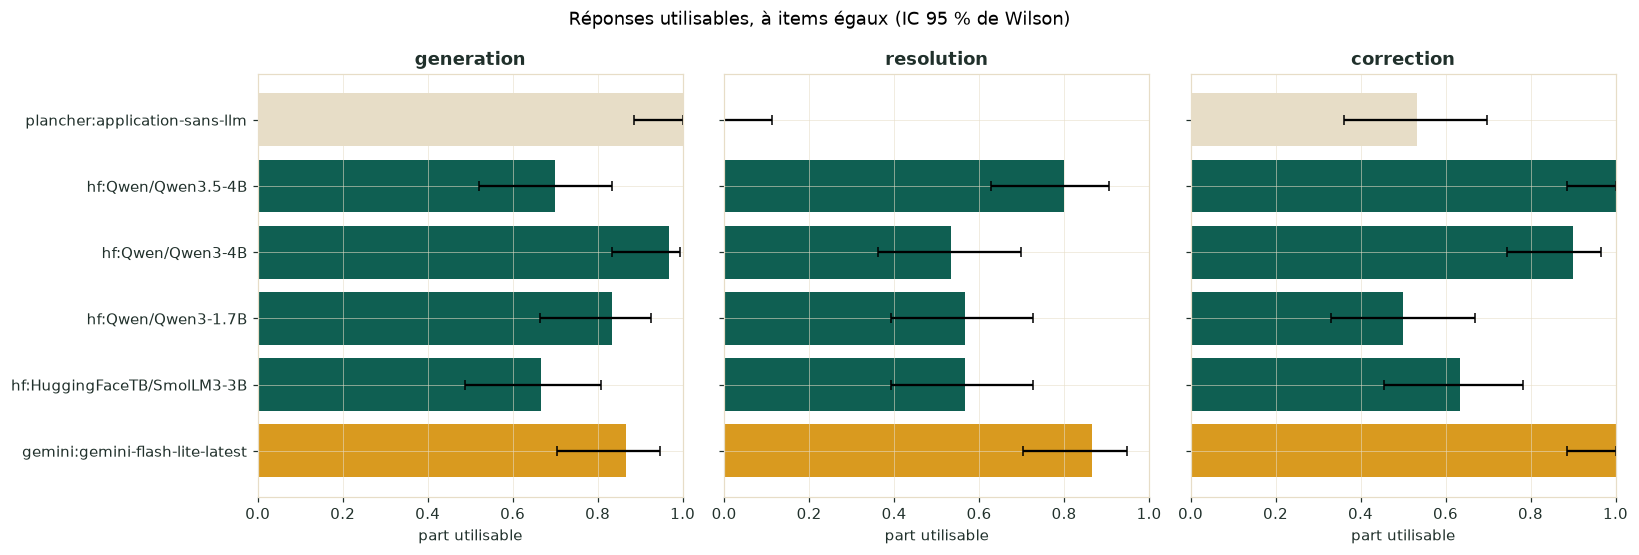

In [4]:
geminis = [m for m in reponses if m.startswith("gemini:")]
if not geminis:
    print("Aucune réponse Gemini collectée pour l'instant.")
else:
    ids_communs = set.intersection(*(set(reponses[m]) for m in geminis))
    r_apparie = banc.rapport(restreindre_a=ids_communs)
    print(f"{len(ids_communs)} items vus par {', '.join(geminis)}")
    t = tableau(r_apparie)
    display(t)

    modeles = [m for m in r_apparie["modeles"] if not m.startswith("controle:")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 0.55 * len(modeles) + 1.8), sharey=True)
    for ax, tache in zip(axes, banc.TACHES):
        valeurs, bas, hauts = [], [], []
        for m in modeles:
            b = r_apparie["modeles"][m]["taches"].get(tache)
            u = b["utilisable"] if b else {"taux": 0, "ic95": (0, 0)}
            v = u["taux"] or 0
            valeurs.append(v)
            bas.append(max(0, v - (u["ic95"][0] if u["ic95"][0] == u["ic95"][0] else v)))
            hauts.append(max(0, (u["ic95"][1] if u["ic95"][1] == u["ic95"][1] else v) - v))
        couleurs = [COULEURS["dore"] if m.startswith("gemini") else
                    COULEURS["lignes"] if m.startswith("plancher") else COULEURS["vert"] for m in modeles]
        ax.barh(modeles, valeurs, xerr=[bas, hauts], color=couleurs, capsize=3)
        ax.set_xlim(0, 1)
        ax.set_title(tache)
        ax.set_xlabel("part utilisable")
    fig.suptitle("Réponses utilisables, à items égaux (IC 95 % de Wilson)")
    fig.tight_layout()
    fig.savefig(pathlib.Path.cwd().parent / "figures/05-utilisable-apparie.png", dpi=150)
    plt.show()

---
## 4. Par niveau

Le plan d'entraînement active le modèle maison **par couple (niveau,
matière)**, seulement là où il atteint les seuils. Ce tableau donne, pour les
modèles évalués sur le jeu complet, la part utilisable par niveau.

In [5]:
def par(cle):
    lignes = []
    for modele, m in r["modeles"].items():
        if modele.startswith(("controle:", "gemini:")):
            continue
        for tache, b in m["taches"].items():
            for groupe, u in b[cle].items():
                lignes.append({"modèle": modele, "tâche": tache, cle.replace("par_", ""): groupe,
                               "utilisable": u["taux"], "n": u["n"]})
    return pd.DataFrame(lignes)

niveaux = par("par_niveau")
if len(niveaux):
    display(niveaux.pivot_table(index=["tâche", "niveau"], columns="modèle", values="utilisable").round(3))

modèle             hf:HuggingFaceTB/SmolLM3-3B  hf:Qwen/Qwen3-1.7B  hf:Qwen/Qwen3-4B  hf:Qwen/Qwen3.5-4B  plancher:application-sans-llm
tâche      niveau                                                                                                                      
correction 4ème                          0.750               0.583             0.667               0.972                          0.472
           5ème                          0.806               0.556             0.917               1.000                          0.472
           6ème                          0.837               0.512             0.837               1.000                          0.442
           BAC                           0.641               0.538             0.936               0.974                          0.487
           BEPC                          0.692               0.542             0.925               0.991                          0.551
generation 4ème                          0.700               0.900             1.000               0.600                          1.000
           5ème                          0.839               0.968             0.968               0.677                          1.000
           6ème                          0.903               0.839             1.000               0.742                          1.000
           BAC                           0.615               0.824             0.967               0.604                          0.978
           BEPC                          0.692               0.914             0.957               0.598                          1.000
resolution 4ème                          0.767               0.733             0.767               0.800                          0.000
           5ème                          0.333               0.633             0.533               0.867                          0.000
           6ème                          0.633               0.600             0.633               1.000                          0.000
           BAC                           0.167               0.167             0.300               0.500                          0.000
           BEPC                          0.300               0.233             0.500               0.733                          0.000

## 5. Par matière

In [6]:
matieres = par("par_matiere")
if len(matieres):
    display(matieres.pivot_table(index=["tâche", "matiere"], columns="modèle", values="utilisable").round(3))

modèle                                        hf:HuggingFaceTB/SmolLM3-3B  hf:Qwen/Qwen3-1.7B  hf:Qwen/Qwen3-4B  hf:Qwen/Qwen3.5-4B  \
tâche      matiere                                                                                                                    
correction Allemand                                                 0.778               0.556             1.000               1.000   
           Anglais                                                  0.583               0.542             1.000               1.000   
           Communication écrite                                     0.333               0.333             0.833               1.000   
           Espagnol                                                 0.889               0.778             1.000               1.000   
           Français                                                 0.556               0.556             1.000               1.000   
           Histoire-Géographie                                      0.636               0.454             1.000               0.954   
           Lecture                                                  0.385               0.308             1.000               0.923   
           Mathématiques                                            0.840               0.653             0.693               1.000   
           Philosophie                                              0.800               0.700             1.000               1.000   
           Physique-Chimie-Technologie                              0.693               0.467             0.853               0.973   
           Sciences de la Vie et de la Terre                        0.792               0.542             1.000               1.000   
generation Allemand                                                 0.692               0.923             0.923               0.692   
           Anglais                                                  0.692               0.962             0.962               0.808   
           Communication écrite                                     0.692               0.846             1.000               0.615   
           Espagnol                                                 0.692               0.923             1.000               0.538   
           Français                                                 0.846               0.923             1.000               0.692   
           Histoire-Géographie                                      0.692               0.962             1.000               0.654   
           Lecture                                                  0.462               1.000             1.000               0.385   
           Mathématiques                                            0.672               0.672             0.906               0.625   
           Philosophie                                              0.692               0.846             1.000               0.462   
           Physique-Chimie-Technologie                              0.679               0.924             0.981               0.566   
           Sciences de la Vie et de la Terre                        0.830               0.981             1.000               0.660   
resolution Mathématiques                                            0.533               0.400             0.480               0.733   
           Physique-Chimie-Technologie                              0.347               0.547             0.613               0.827   

modèle                                        plancher:application-sans-llm  
tâche      matiere                                                           
correction Allemand                                                   0.556  
           Anglais                                                    0.500  
           Communication écrite                                       0.833  
           Espagnol                                                   0.333  
           Français  

---
## 6. Ce qui rend une réponse inutilisable

Parmi les réponses **conformes au schéma**, la part touchée par chaque défaut.
Une réponse non conforme (JSON absent ou incomplet) est comptée à part, dans
la colonne `non conforme`.

In [7]:
lignes = []
for modele, m in r["modeles"].items():
    if modele.startswith("controle:"):
        continue
    for tache, b in m["taches"].items():
        ligne = {"modèle": modele, "tâche": tache, "non conforme": round(1 - b["conforme"]["taux"], 3)}
        for d in ("latex", "desaccentue", "anglais"):
            ligne[d] = b[d]["taux"]
        if tache == "generation":
            ligne["trop court"] = None if b["longueurs_ok"]["taux"] is None else round(1 - b["longueurs_ok"]["taux"], 3)
        lignes.append(ligne)
pd.DataFrame(lignes).set_index(["tâche", "modèle"]).sort_index()

non conforme   latex  desaccentue  anglais  trop court
tâche      modèle                                                                                 
correction gemini:gemini-flash-lite-latest         0.000  0.0000       0.0000      0.0         NaN
           hf:HuggingFaceTB/SmolLM3-3B             0.063  0.0000       0.0000      0.0         NaN
           hf:Qwen/Qwen3-1.7B                      0.097  0.0000       0.0042      0.0         NaN
           hf:Qwen/Qwen3-4B                        0.100  0.0000       0.0000      0.0         NaN
           hf:Qwen/Qwen3.5-4B                      0.007  0.0000       0.0000      0.0         NaN
           plancher:application-sans-llm           0.000  0.0000       0.0000      0.0         NaN
generation gemini:gemini-flash-lite-latest         0.033  0.0000       0.1200      0.0       0.000
           hf:HuggingFaceTB/SmolLM3-3B             0.290  0.0000       0.0000      0.0       0.000
           hf:Qwen/Qwen3-1.7B                      0.073  0.0396       0.0044      0.0       0.004
           hf:Qwen/Qwen3-4B                        0.027  0.0000       0.0041      0.0       0.000
           hf:Qwen/Qwen3.5-4B                      0.373  0.0053       0.0000      0.0       0.000
           plancher:application-sans-llm           0.000  0.0000       0.0081      0.0       0.000
resolution gemini:gemini-flash-lite-latest         0.100  0.0000       0.0000      0.0         NaN
           hf:HuggingFaceTB/SmolLM3-3B             0.147  0.0000       0.0000      0.0         NaN
           hf:Qwen/Qwen3-1.7B                      0.067  0.0143       0.0000      0.0         NaN
           hf:Qwen/Qwen3-4B                        0.127  0.0000       0.0000      0.0         NaN
           hf:Qwen/Qwen3.5-4B                      0.007  0.0000       0.0134      0.0         NaN
           plancher:application-sans-llm           1.000     NaN          NaN      NaN         NaN

### 6 bis. Réponses coupées par la limite de jetons du banc

In [8]:
lignes = []
for modele, rep in reponses.items():
    if not modele.startswith("hf:"):
        continue
    par_tache = {}
    for id_, e in rep.items():
        tache = next(i["tache"] for i in jeu if i["id"] == id_)
        par_tache.setdefault(tache, []).append(e.get("jetons_sortie", 0) >= 1024)
    lignes.append({"modèle": modele, **{t: f"{sum(v)} / {len(v)}" for t, v in sorted(par_tache.items())}})
pd.DataFrame(lignes).set_index("modèle")

,correction,generation,resolution
modèle,,,
hf:HuggingFaceTB/SmolLM3-3B,2 / 300,8 / 300,11 / 150
hf:Qwen/Qwen3-1.7B,0 / 300,3 / 300,0 / 150
hf:Qwen/Qwen3-4B,0 / 300,3 / 300,1 / 150
hf:Qwen/Qwen3.5-4B,0 / 300,79 / 300,1 / 150


---
## 7. Thèmes réservés

19 thèmes (un par matière qui en compte au moins quatre) sont **exclus du
futur jeu d'entraînement** (`exclusions.json`). Après la phase 3, comparer la
part utilisable sur ces thèmes à celle des autres dira si le modèle affiné
généralise ou s'il a appris par cœur. Avant entraînement, les deux doivent
être proches : c'est le point de départ.

In [9]:
lignes = []
for modele, m in r["modeles"].items():
    g = m["taches"].get("generation")
    if not g or modele.startswith("controle:"):
        continue
    lignes.append({"modèle": modele, "thèmes réservés": g["themes_reserves"]["taux"],
                   "n réservés": g["themes_reserves"]["n"], "tous thèmes": g["utilisable"]["taux"]})
pd.DataFrame(lignes).set_index("modèle")

,thèmes réservés,n réservés,tous thèmes
modèle,,,
gemini:gemini-flash-lite-latest,0.6667,3,0.8667
hf:HuggingFaceTB/SmolLM3-3B,0.5833,36,0.7067
hf:Qwen/Qwen3-1.7B,0.8333,36,0.8833
hf:Qwen/Qwen3-4B,1.0000,36,0.9700
hf:Qwen/Qwen3.5-4B,0.4722,36,0.6233
plancher:application-sans-llm,1.0000,36,0.9933


---
## Lecture des résultats (collecte du 2026-09-25)

**Deux profils opposés parmi les 4 B.** Qwen3-4B soigne la forme : c'est le
meilleur en génération, mais il ne résout juste qu'environ six exercices
calculés sur dix, et moins d'un tiers au BAC. Qwen3.5-4B raisonne mieux —
résolution et correction au niveau de Gemini flash-lite sur les items
communs, compte tenu des intervalles — mais sa génération est plombée par sa
verbosité : une réponse sur quatre dépasse la limite de 1 024 jetons du banc.

**Ce qui départage : ce que l'affinage sait corriger.** Un format (JSON
compact, pas de gras dans une valeur, explication plus courte) s'apprend en
quelques milliers d'exemples ; c'est précisément ce que contient le jeu de la
phase 2. Une compétence de raisonnement mathématique, beaucoup moins. D'où la
recommandation de la phase 1 : **partir de Qwen3.5-4B**, sous réserve qu'un
essai court sur Kaggle confirme que son architecture (attention hybride) se
laisse affiner en QLoRA sur un T4 — sinon Qwen3-4B.

**Les petits modèles sont écartés.** Qwen3-1.7B laisse passer 84 % des
réponses fausses d'élève en correction ; SmolLM3-3B est en dessous des Qwen
sur les trois tâches.

**Rien n'est encore gagné.** Aucun modèle ouvert n'atteint, sans
entraînement, les seuils de la phase 4. C'est le point de départ que le
modèle affiné devra dépasser, sur ce même banc.

---
## 8. Limites

- **La justesse d'un exercice généré n'est pas mesurée.** Pour la tâche
  `generation`, on juge le format et l'écriture, pas la vérité de la solution
  proposée : aucune référence n'existe pour un exercice inventé. La justesse
  mathématique est mesurée à part, sur la tâche `resolution`, et la relecture
  humaine de la phase 4 reste indispensable.
- **« Utilisable » en génération juge la forme, pas le fond.** Le plancher
  (la banque de secours) y obtient presque 100 % : ses exercices, validés à
  la main, sont impeccables sur la forme — mais ils ne suivent pas toujours
  le thème demandé et se répètent. Ni l'adéquation au thème, ni la variété,
  ni la justesse ne sont mesurées ici pour cette tâche ; elles relèvent de la
  relecture humaine (phase 4) ou d'un juge automatique à construire.
- **La résolution ne couvre que Mathématiques et Physique-Chimie**, les deux
  matières dotées de générateurs. La justesse compare les *nombres* de la
  solution (appariement un pour un, tolérance d'une unité sur la dernière
  décimale écrite) : une réponse juste mais rédigée sans ses nombres
  (« l'ensemble vide ») serait comptée fausse. Les nombres de la référence
  qui redisent une donnée de l'énoncé (« 9 m = 900 cm ») ne sont pas exigés.
- **Les réponses d'élève sont fabriquées.** Justes : la solution, parfois sans
  son « x = ». Fausses : un nombre faussé, ou la solution d'un exercice d'un
  autre thème. De vraies erreurs d'élèves sont plus subtiles ; ce banc mesure
  un plancher de compétence, pas la performance en classe.
- **Les détecteurs de défauts sont des heuristiques** (liste de mots français
  qui exigent un accent, élisions sans apostrophe, mots-outils anglais). Ils
  sont validés par l'autotest de la section 1 et par un contrôle manuel sur
  le plancher, pas par une annotation humaine systématique.
- **Les modèles ouverts sont bridés à 1 024 jetons de réponse** (Gemini :
  8 192 en production). Une réponse coupée est un JSON incomplet, donc non
  conforme. Qwen3.5-4B, le plus bavard, en perd 78 en génération : son score
  de génération mesure autant sa verbosité que sa compétence. La section 6
  bis compte ces troncatures modèle par modèle.
- **Gemini n'est mesuré que sur un sous-échantillon**, et sa disponibilité
  varie : `gemini-3.5-flash` renvoyait des erreurs 503 (« high demand ») le
  jour de la collecte. Le modèle mesuré est indiqué dans chaque ligne.